In [242]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from numpy.f2py.crackfortran import neededmodule

| **Column Name** | **Description**                                                                                  |
|-----------------|--------------------------------------------------------------------------------------------------|
| **country**     | Name of the country                                                                              |
| **child_mort**  | Death of children under 5 years of age per 1000 live births                                      |
| **exports**     | Exports of goods and services per capita (% of GDP per capita)                                   |
| **health**      | Total health spending per capita (% of GDP per capita)                                           |
| **imports**     | Imports of goods and services per capita (% of GDP per capita)                                   |
| **income**      | Net income per person                                                                            |
| **inflation**   | Annual growth rate of the Total GDP                                                              |
| **life_expec**  | Average number of years a newborn child would live if current mortality patterns remain the same |
| **total_fer**   | Number of children born to each woman if current age-fertility rates remain the same             |
| **gdpp**        | GDP per capita (Total GDP divided by total population)                                           |


In [243]:
data = pd.read_csv("29-unsupervised_learning_country_data.csv")

In [244]:
data

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200
...,...,...,...,...,...,...,...,...,...,...
162,Vanuatu,29.2,46.6,5.25,52.7,2950,2.62,63.0,3.50,2970
163,Venezuela,17.1,28.5,4.91,17.6,16500,45.90,75.4,2.47,13500
164,Vietnam,23.3,72.0,6.84,80.2,4490,12.10,73.1,1.95,1310
165,Yemen,56.3,30.0,5.18,34.4,4480,23.60,67.5,4.67,1310


In [245]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [246]:
data.isnull().sum()

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

In [247]:
data.columns

Index(['country', 'child_mort', 'exports', 'health', 'imports', 'income',
       'inflation', 'life_expec', 'total_fer', 'gdpp'],
      dtype='object')

In [248]:
data.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


In [249]:
import math

def all_hist(data, title_pre = ""):
    num_cols = data.select_dtypes(include=[np.number]).columns
    n_cols = 3
    n_rows = math.ceil(len(num_cols) / n_cols)

    plt.figure(figsize=(4*n_rows, 5*n_cols))

    for i, col in enumerate(num_cols, 1):
        plt.subplot(n_rows, n_cols, i)
        sns.histplot(data[col], kde=True, bins=30)
        plt.title(f"{title_pre} {col}")
        plt.xlabel("")

    plt.tight_layout()
    plt.show()

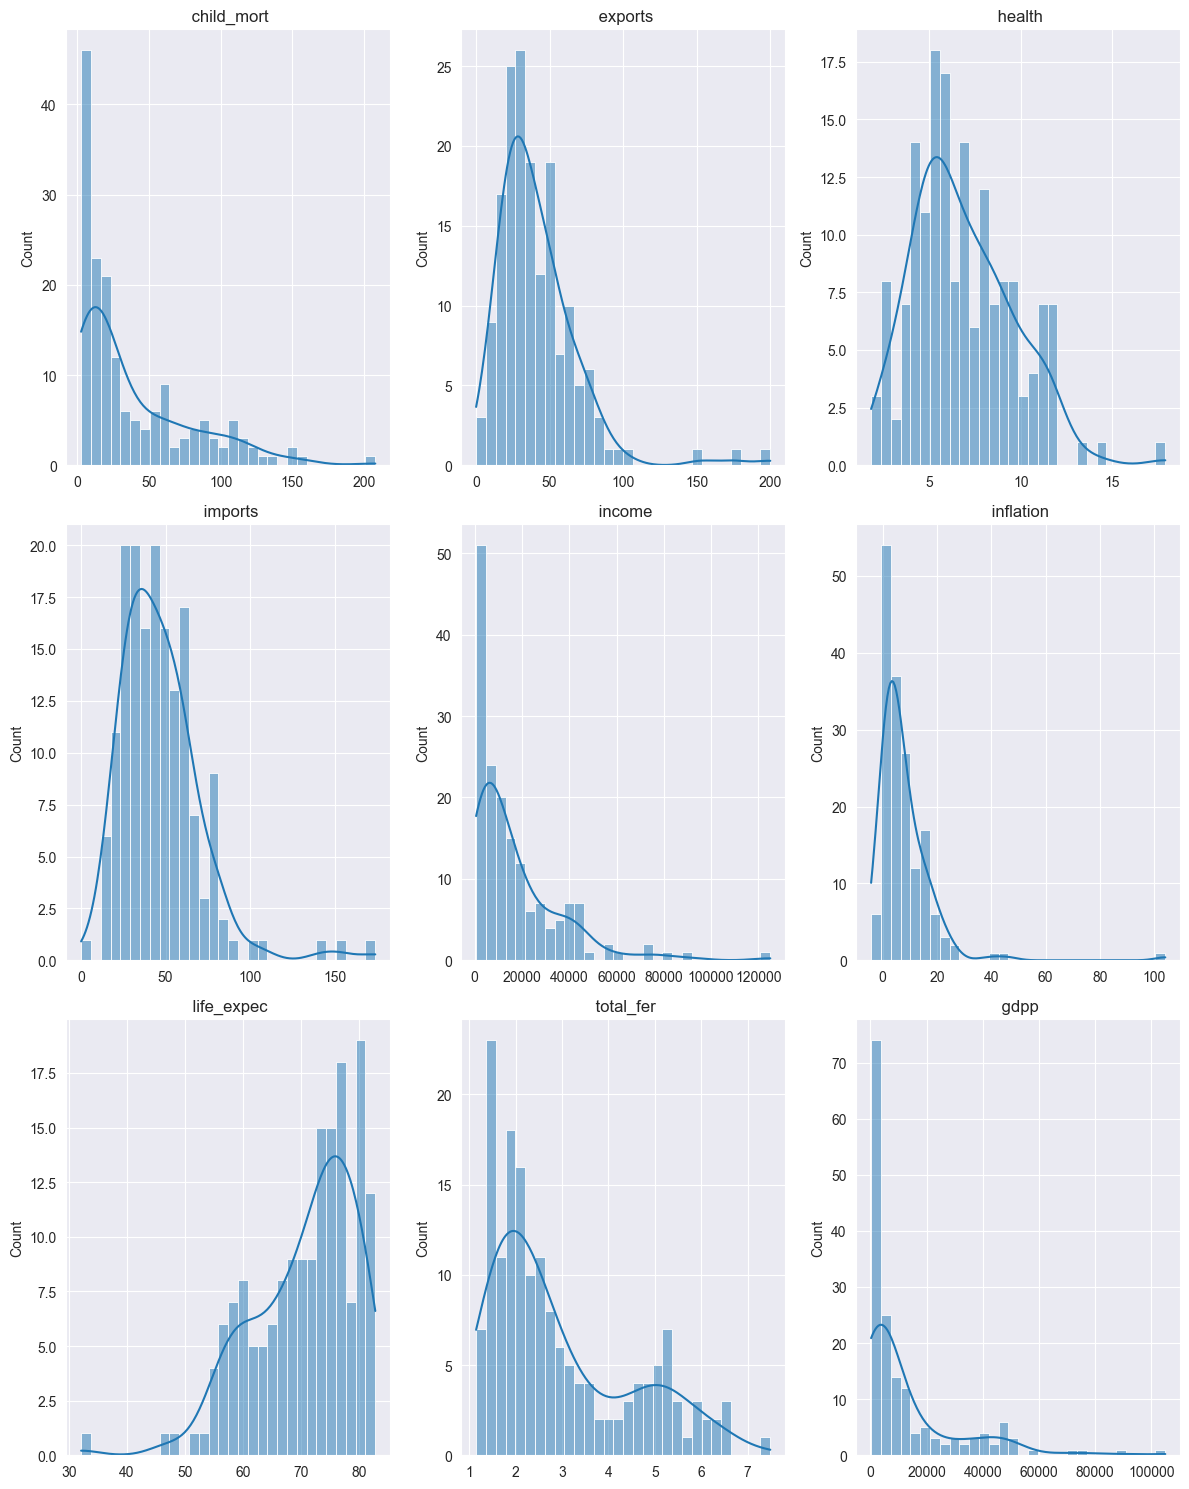

In [250]:
all_hist(data)

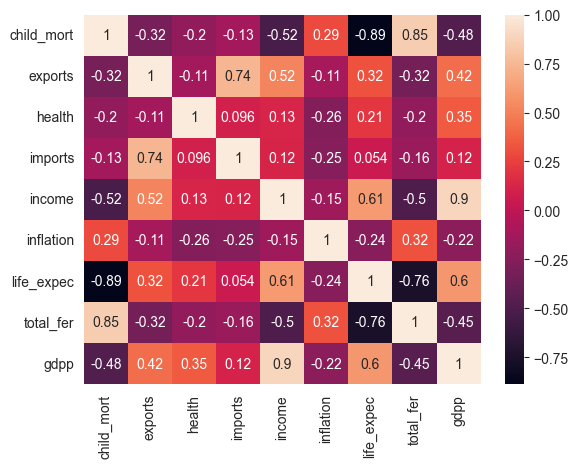

In [251]:
sns.heatmap(data.corr(numeric_only=True), annot=True)
plt.show()

In [252]:
data2 = data.drop("country", axis=1)

In [253]:
data2.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [254]:
from sklearn.preprocessing import MinMaxScaler

In [255]:
scaler = MinMaxScaler()

In [256]:
data2 = scaler.fit_transform(data2)

In [257]:
data2 = pd.DataFrame(data2, columns=['child_mort', 'exports', 'health', 'imports', 'income',
       'inflation', 'life_expec', 'total_fer', 'gdpp'])

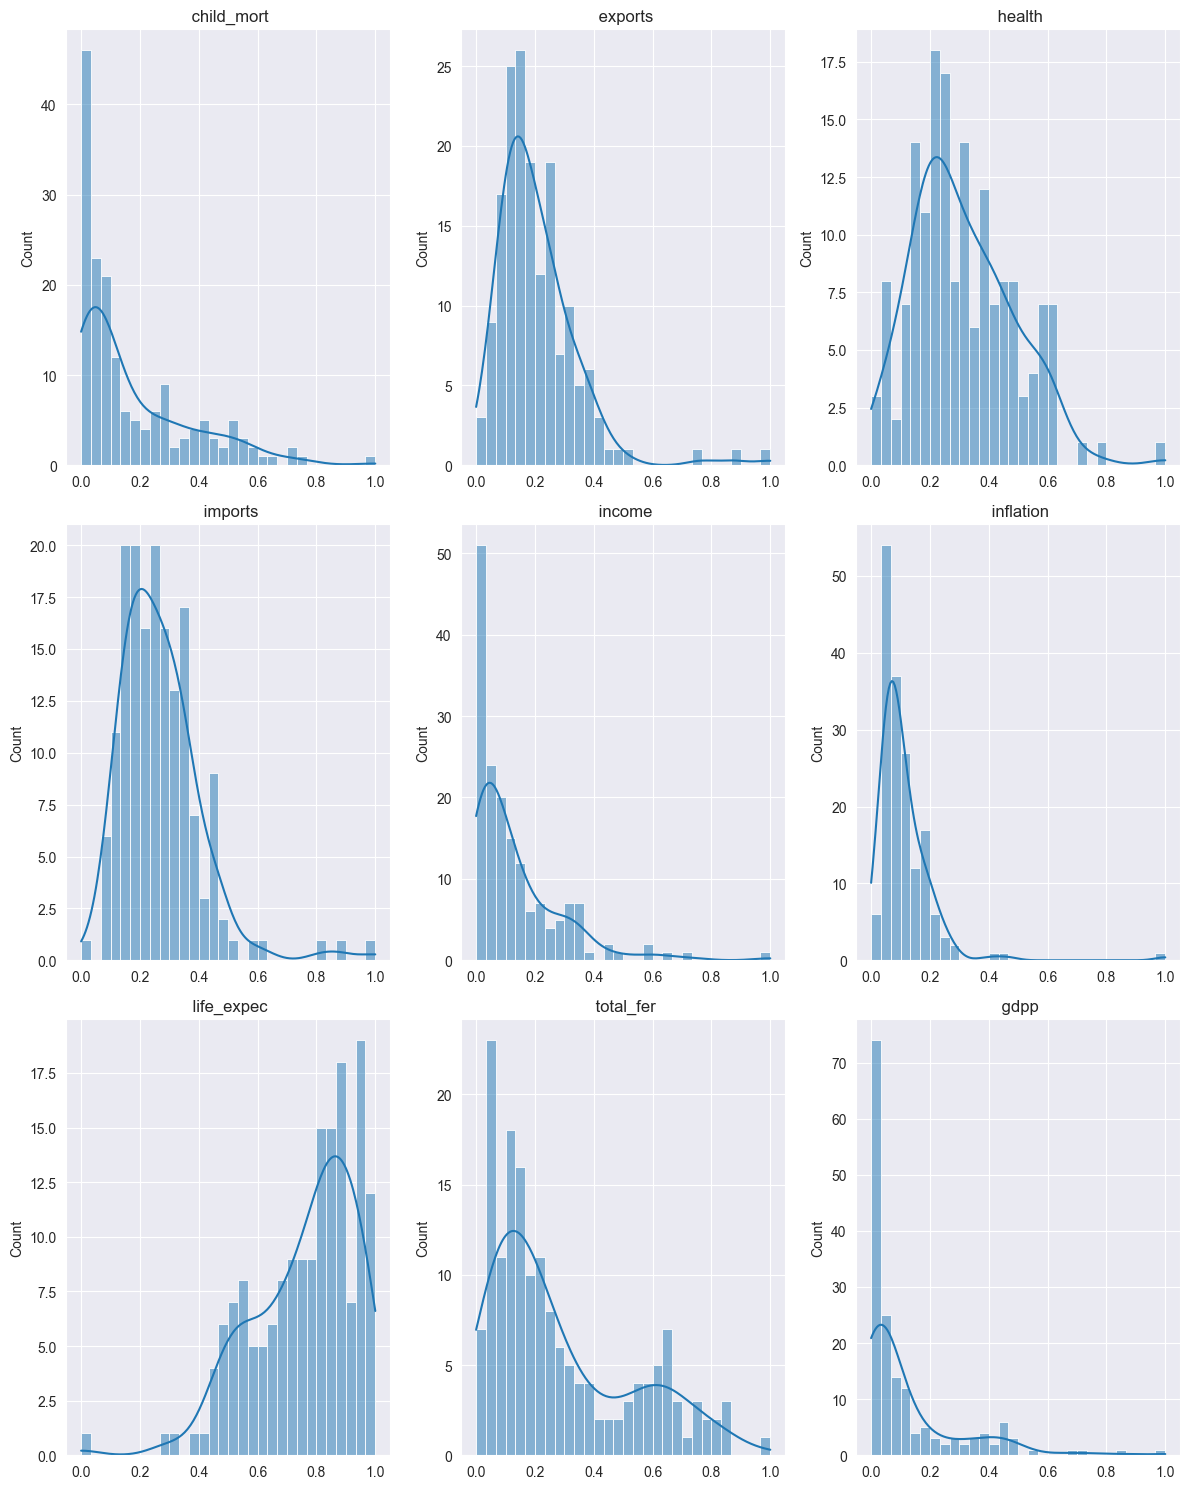

In [258]:
all_hist(data2)

In [259]:
from sklearn.decomposition import PCA

In [260]:
pca = PCA()

In [261]:
pca_data2 = pd.DataFrame(pca.fit_transform(data2))

In [262]:
pca_data2

,0,1,2,3,4,5,6,7,8
0,0.599078,0.095490,0.157554,0.024333,0.045618,-0.046532,-0.076803,-0.040610,0.023572
1,-0.158474,-0.212092,-0.064189,0.061247,-0.014191,-0.010246,0.043567,-0.030842,0.029833
2,-0.003686,-0.135867,-0.134182,-0.133574,0.091150,0.025988,0.045604,0.010198,0.003012
3,0.650235,0.275975,-0.142672,-0.156018,0.081997,0.032170,0.073985,0.045195,-0.042241
4,-0.200711,-0.064662,-0.100715,0.037902,0.035799,-0.055817,0.009559,-0.026228,0.022455
...,...,...,...,...,...,...,...,...,...
162,0.160078,-0.029625,-0.121910,0.066099,0.009043,-0.063646,-0.115254,0.003232,-0.065701
163,-0.061133,-0.171339,-0.058586,-0.247460,0.093260,0.291515,-0.005521,-0.056038,-0.036459
164,-0.115512,-0.032034,-0.195243,0.231993,0.035734,0.089237,0.039743,0.006124,-0.017780
165,0.332968,-0.019824,-0.029989,-0.105416,0.141550,0.063254,-0.012519,-0.014231,-0.011441


In [263]:
pca.explained_variance_ratio_

array([0.55001227, 0.13384784, 0.12301053, 0.09749047, 0.03777964,
       0.03013659, 0.01190434, 0.00887791, 0.00694042])

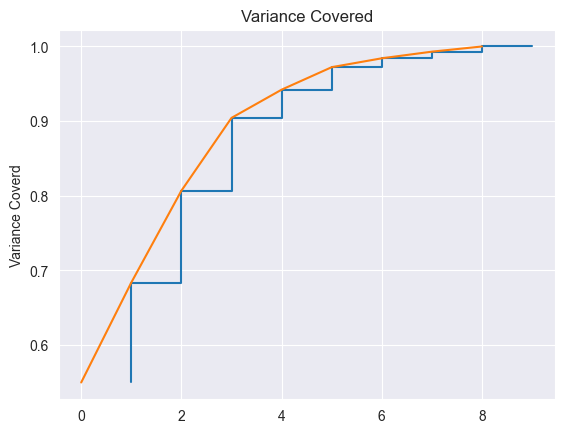

In [264]:
plt.step(list(range(1,10)), np.cumsum(pca.explained_variance_ratio_))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.ylabel("Variance Coverd")
plt.title("Variance Covered")
plt.show()

In [265]:
pca_data2 = pca_data2.drop(columns=[3, 4, 5, 6, 7, 8])

In [266]:
pca_data2

,0,1,2
0,0.599078,0.095490,0.157554
1,-0.158474,-0.212092,-0.064189
2,-0.003686,-0.135867,-0.134182
3,0.650235,0.275975,-0.142672
4,-0.200711,-0.064662,-0.100715
...,...,...,...
162,0.160078,-0.029625,-0.121910
163,-0.061133,-0.171339,-0.058586
164,-0.115512,-0.032034,-0.195243
165,0.332968,-0.019824,-0.029989


In [267]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [268]:
wcss = []

for k in range(1,11):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(pca_data2)
    wcss.append(kmeans.inertia_)

In [269]:
wcss

[34.53302925308176,
 17.68595420957708,
 11.270622261541497,
 9.019966310735,
 7.264000917109453,
 6.288487013757903,
 5.722301855820714,
 5.1304855985249445,
 4.689345032351406,
 4.06855973075024]

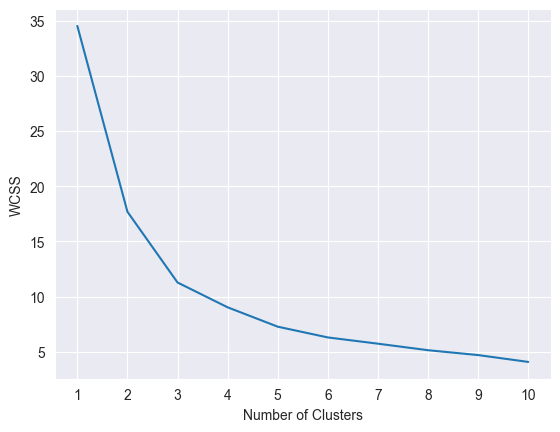

In [270]:
plt.plot(range(1,11), wcss)
plt.xticks(range(1,11))
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [271]:
model = KMeans(n_clusters=3)
model.fit(pca_data2)

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [272]:
labels = model.labels_

In [273]:
silhouette_score(pca_data2, labels)

0.43863203452366817

In [274]:
data["Class"] = labels

In [275]:
data

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Class
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,1
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,2
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,2
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,1
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,2
...,...,...,...,...,...,...,...,...,...,...,...
162,Vanuatu,29.2,46.6,5.25,52.7,2950,2.62,63.0,3.50,2970,2
163,Venezuela,17.1,28.5,4.91,17.6,16500,45.90,75.4,2.47,13500,2
164,Vietnam,23.3,72.0,6.84,80.2,4490,12.10,73.1,1.95,1310,2
165,Yemen,56.3,30.0,5.18,34.4,4480,23.60,67.5,4.67,1310,1


Text(0.5, 1.0, 'Income vs. Class')

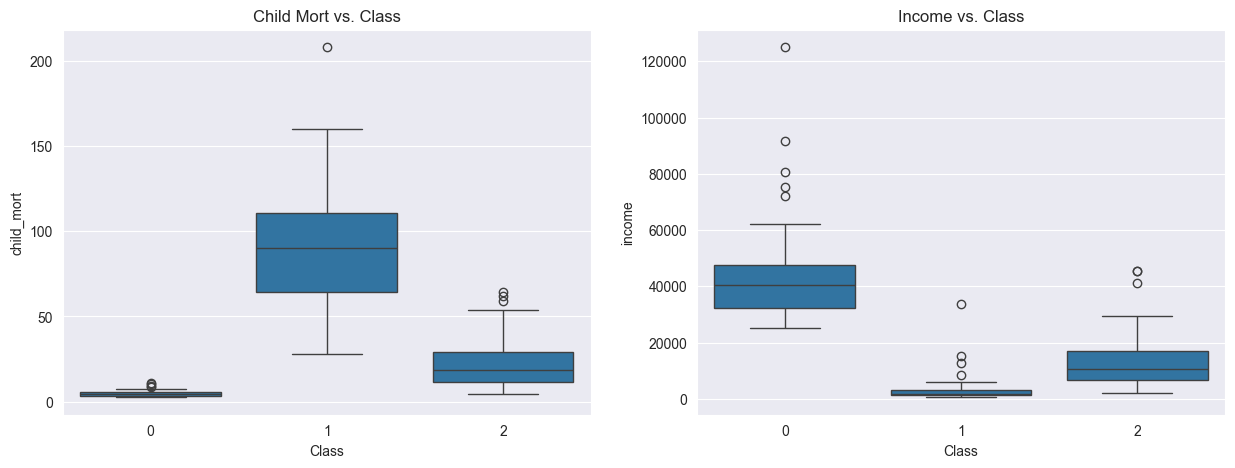

In [276]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15,5))

plt.subplot(1,2,1)
sns.boxplot(data=data, x="Class", y="child_mort")
plt.title("Child Mort vs. Class")

plt.subplot(1,2,2)
sns.boxplot(data=data, x="Class", y="income")
plt.title("Income vs. Class")

In [ ]:
# 0 -> no budget needed
# 1 -> budget needed
# 2 -> in between

In [277]:
import plotly.express as px

In [278]:
pca_data2.insert(0, column="Country", value=data["country"])

In [279]:
pca_data2["Class"] = labels

In [280]:
pca_data2.loc[pca_data2["Class"] == 0, "Class"] = "No Budget Needed"
pca_data2.loc[pca_data2["Class"] == 1, "Class"] = "Budget Needed"
pca_data2.loc[pca_data2["Class"] == 2, "Class"] = "In Between"

C:\Users\Muham\AppData\Local\Temp\ipykernel_9160\602718873.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'No Budget Needed' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.
  pca_data2.loc[pca_data2["Class"] == 0, "Class"] = "No Budget Needed"


In [281]:
pca_data2

,Country,0,1,2,Class
0,Afghanistan,0.599078,0.095490,0.157554,Budget Needed
1,Albania,-0.158474,-0.212092,-0.064189,In Between
2,Algeria,-0.003686,-0.135867,-0.134182,In Between
3,Angola,0.650235,0.275975,-0.142672,Budget Needed
4,Antigua and Barbuda,-0.200711,-0.064662,-0.100715,In Between
...,...,...,...,...,...
162,Vanuatu,0.160078,-0.029625,-0.121910,In Between
163,Venezuela,-0.061133,-0.171339,-0.058586,In Between
164,Vietnam,-0.115512,-0.032034,-0.195243,In Between
165,Yemen,0.332968,-0.019824,-0.029989,Budget Needed


In [295]:
fig = px.choropleth(
    pca_data2[["Country", "Class"]],
    locationmode="country names",
    locations="Country",
    title = "Needed Budget by Country",
    color = pca_data2["Class"],
    color_discrete_map={
        "Budget Needed": "Red",
        "In Between": "Yellow",
        "No Budget Needed": "Green",
    })

fig.update_geos(
    projection_type="orthographic",  # "mercator", "orthographic", "equirectangular", "natural earth"
    showcoastlines=True,
    coastlinecolor="LightGray",
    showland=True,
    landcolor="whitesmoke",
    showocean=True,
    oceancolor="lightblue"
)


fig.update_layout(legend_title_text="Budget Classification")
fig.add_annotation(
    text="Source: PCA-based classification of budget needs",
    xref="paper", yref="paper",
    x=0, y=-0.1,
    showarrow=False,
    font=dict(size=10)
)

fig.update_layout(
    title={
        "text": "Needed Budget by Country<br><sup>Classification of countries based on budget requirements</sup>",
        "x": 0.5,
        "xanchor": "center"
    }
)

fig.show()

C:\Users\Muham\AppData\Local\Temp\ipykernel_9160\1034295080.py:1: DeprecationWarning:

The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.

